# limit_chart function demo

In [1]:
# Import libraries
from process_improvement.charts.limit_charts import limit_chart
from process_improvement.charts.utils import LimitChartConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("shewharts_resistance_measurements")

initial_df = df[df['Stage'] == 'Initial']

df.head()

,Stage,Units,Value,Resistance
0,Initial,megohms,1.0,5045.0
1,Initial,megohms,2.0,4350.0
2,Initial,megohms,3.0,4350.0
3,Initial,megohms,4.0,3975.0
4,Initial,megohms,5.0,4290.0


## Specification Limit

In [4]:
USL = 5295
LSL = 3395
tolerance = USL - LSL
Target = LSL + (tolerance/2)

## Configuration and limit chart

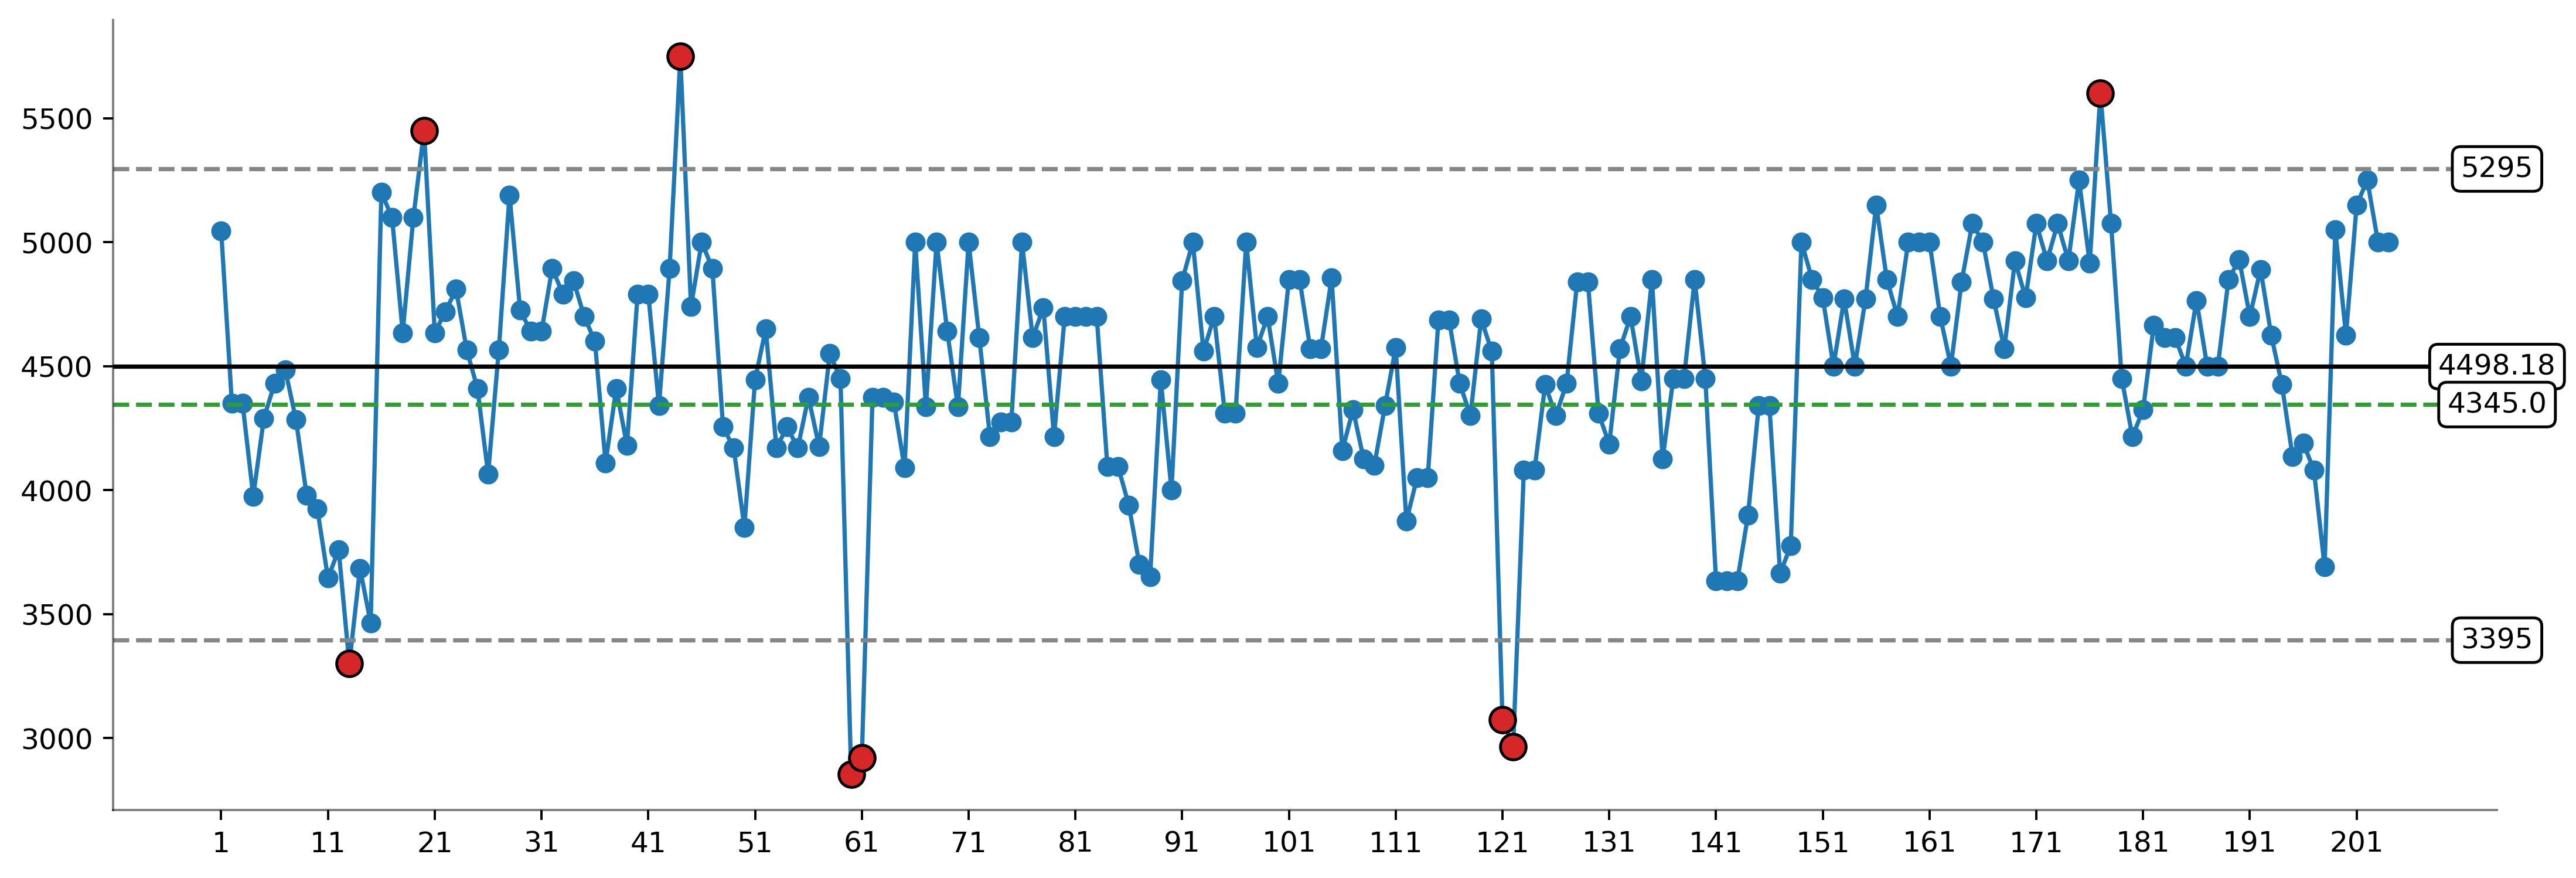

In [5]:
# Configuration
config = LimitChartConfig(
    figsize=(15,5),
    tickinterval=10
)

# Create XmR chart
results = limit_chart(
    df=initial_df,
    values='Resistance',
    x_labels='Value',
    USL=USL,
    LSL=LSL,
    Target=Target,
    config=config
)

## Show process statistics

In [6]:
# Show statistics
round(results.stats_df, 2)

,Chart,Process Stats,Values
0,Limit chart,Mean,4498.18
1,Limit chart,USL,5295.00
2,Limit chart,LSL,3395.00
3,Limit chart,Count > USL,3.00
4,Limit chart,Count < LSL,5.00
5,Limit chart,Total Outside Limits,8.00


## Alternate configuration and limit chart

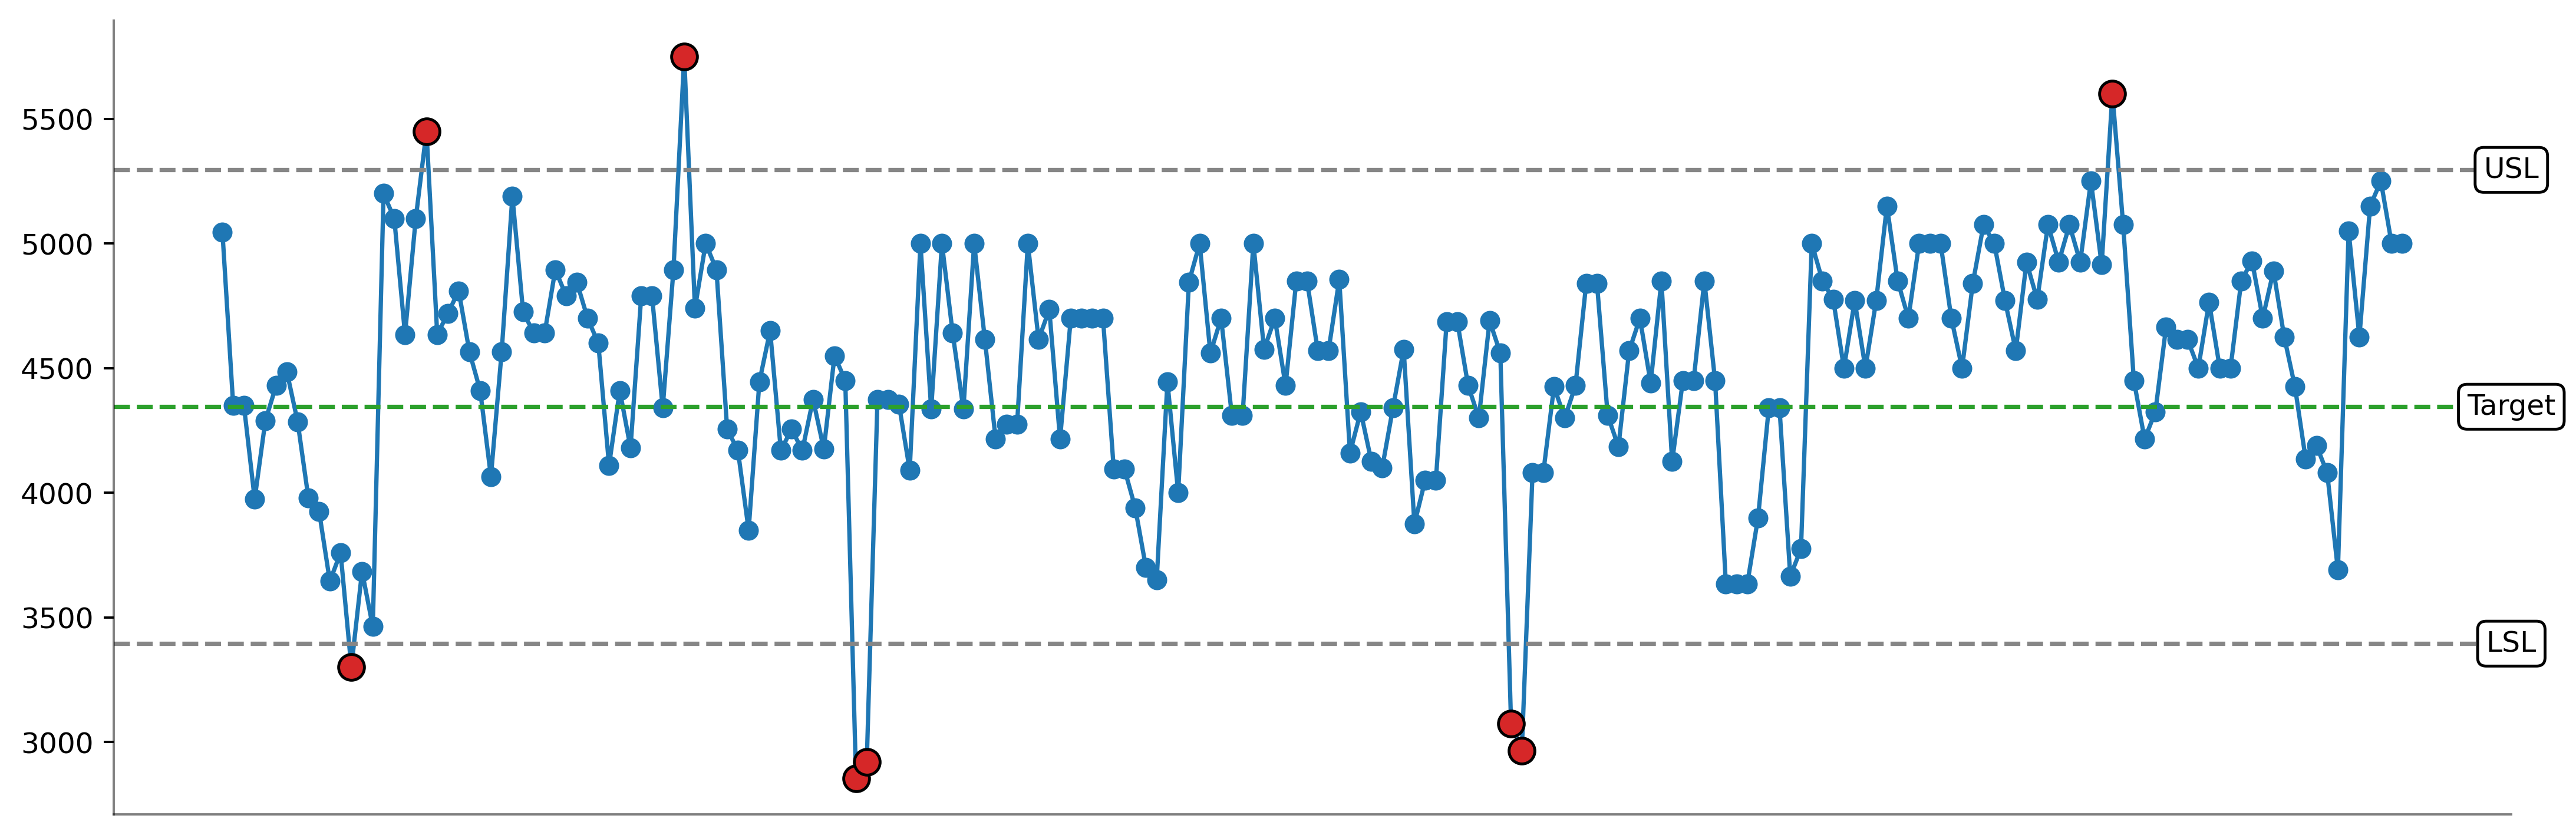

In [10]:
# Configuration
config2 = LimitChartConfig(
    figsize=(15,5),
    tickinterval=10,
    show_xticks=False,
    show_ytick_labels=True,
    linestyle='-', # Works
    show_label_values=False,
    show_mean=False
)

# Create XmR chart
results2 = limit_chart(
    df=initial_df,
    values='Resistance',
    x_labels='Value',
    USL=USL,
    LSL=LSL,
    Target=Target,
    config=config2
)